# Matplotlib Basics and Stateful Plotting


```{contents}
:local:
:depth: 2
```



## Introduction

Matplotlib is the foundational plotting library in the Python ecosystem, originally developed by John D. Hunter to provide MATLAB-like plotting capabilities in Python. It offers a rich, programmatic interface for producing publication-quality 2D graphics. For a history and introduction of Matplotlib, see matplotlib.org's [History](https://matplotlib.org/stable/project/history.html) section.

For data scientists, Matplotlib is valuable both as a plotting tool and as the underlying engine for fine-grained customization when presentation quality and plot element control matter.

Matplotlib sits at a low level in the Python visualization stack:

1. Many higher-level libraries, such as Pandas plotting methods and Seaborn, build on top of it.
2. It interoperates smoothly with NumPy arrays and the broader scientific Python toolchain.
3. It can be used through two main interfaces:
   1. The **stateful pyplot API** is convenient for quick, one-off plots.
   2. The **object-oriented (OO) API** is the recommended default for most work because it makes figure and axes management explicit.

A useful rule of thumb is:

- Use `plt.plot()` for quick interactive work.
- Use `plt.subplots()` for most real plotting tasks.
- Use `fig.add_axes()` when you need manual placement or inset axes.

Matplotlib has excellent official documentation and examples at https://matplotlib.org/ (see the [Tutorials](https://matplotlib.org/stable/tutorials/index.html) and [Examples](https://matplotlib.org/stable/gallery/index.html)).


### Installation 

You'll need to install matplotlib first with either using `pip` in the terminal:

    pip install matplotlib     ### in terminal with .venv enabled
or using `%pip` in the notebook:

    %pip install matplotlib    ### in Jupyter Notebook

Import the `matplotlib.pyplot` module with alias `plt`:
```python
import matplotlib.pyplot as plt
```

The usual headers for what we are learning so far would look like the cell below (you can activate Live Code and install the missing packages when needed):

In [3]:
import numpy as np
import pandas as pd

# %pip install matplotlib   ### uncomment to install matplotlib if you don't have it already
import matplotlib.pyplot as plt


### Two Styles of Matplotlib Syntax

There are two common styles of Matplotlib plotting:

1. **Stateful pyplot style**: concise and convenient for quick plots.
2. **Object-oriented (OO) style**: more explicit and easier to scale to multi-axes figures.



Note on rendering visualizations:

- In Jupyter notebooks, plots usually display automatically.
- Outside notebooks, you will often need `plt.show()` to display the figure window.
- In older Jupyter/IPython setups, `%matplotlib inline` may still be needed.



## Stateful Matplotlib

The MATLAB-style pyplot API uses stateful functions such as `plt.plot()`, `plt.xlabel()`, and `plt.title()` to build a figure. It is useful for quick exploration, but it becomes harder to manage as figures grow more complex.


### Basic Matplotlib Commands

The table below compares common `plt.plot()` tasks with the corresponding Pandas `df.plot()` usage.

| Task     | Matplotlib plt.plot()  | Pandas df.plot()                      | Notes                                                           |
|----------|------------------------|---------------------------------------|---------------------------------------------------------------|
| figsize  | `plt.figure(figsize)`  | `df.plot(figsize=(m, n))`             | Use `plt.figure()` to setup figure size before `plt.plot()`     |
| To plot  | `plt.plot(x, y)`       | `df.plot(x="x", y="y")` or `s.plot()` | Uses DataFrame/Series directly; x defaults to index if omitted. |
| X label  | `plt.xlabel("X")`      | `df.plot(xlabel=...)`                 | `df.plot(...)` returns an `Axes`; set labels on it.             |
| Y label  | `plt.ylabel("Y")`      | `df.plot(ylabel=...)`                 | Same pattern as label.                                          |
| Title    | `plt.title("My Plot")` | `df.plot(title="My Plot")`            | Pandas supports `title=` in `plot`                              |


Pandas `.plot()` is a convenience wrapper around Matplotlib for quick DataFrame visualization. Compared with `plt.plot()`, the main differences are:

| Feature | `plt.plot()` | Pandas `.plot()` |
|---------|--------------|-------------|
| Typical use | Fine-grained, figure-level control | Fast EDA from DataFrame/Series |
| Built on | Core matplotlib | Wrapper around matplotlib |
| Customization | Full control | Limited, but can access underlying axes |
| Data Input | Expects x/y arrays | Pandas columns/index |

### First Plots

Let’s walk through a simple example with two NumPy arrays. Lists work too, but you’ll usually pass NumPy arrays or Pandas columns, which behave like arrays. The data we want to plot:

In [4]:
import numpy as np

x = np.linspace(0, 5, 11)     ### 11 numbers from 0 to 5, inclusive
y = x ** 2

print(f"x {type(x)}: {x}")
print(f"y {type(y)}: {y}")

x <class 'numpy.ndarray'>: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]
y <class 'numpy.ndarray'>: [ 0.    0.25  1.    2.25  4.    6.25  9.   12.25 16.   20.25 25.  ]


The following code creates a basic line plot:
- `plt.figure()`
- `plt.plot()`

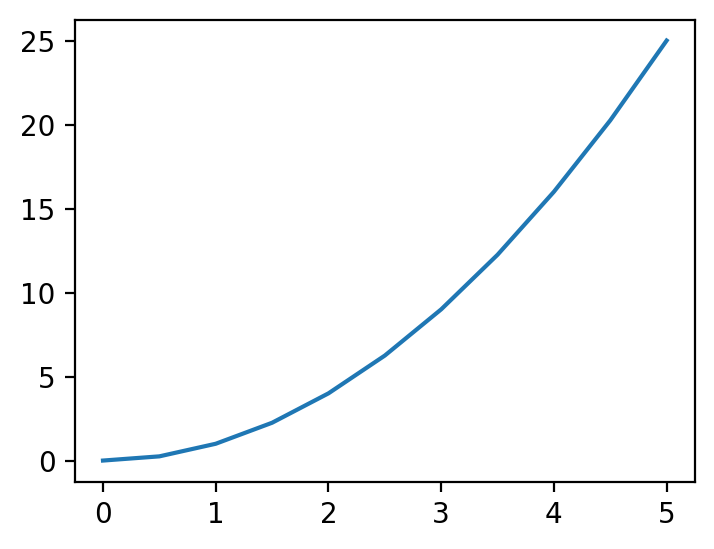

In [5]:
plt.figure(figsize=(4,3))          
plt.plot(x, y)               

You can also create a scatter plot with `plt.scatter()`.


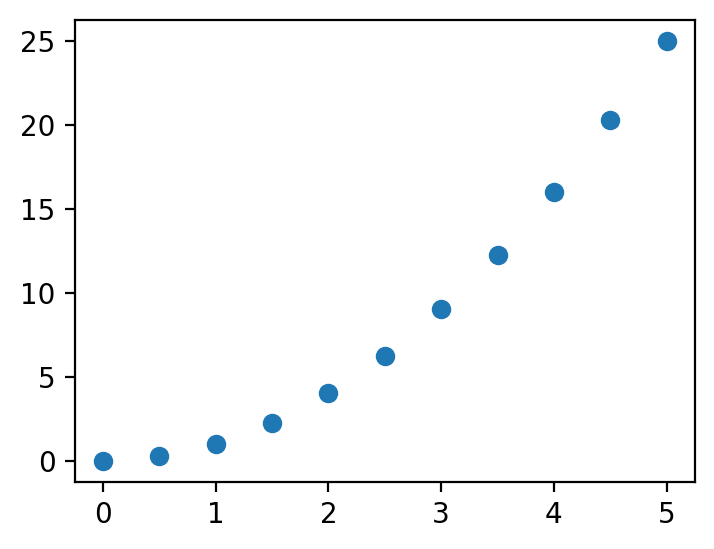

In [6]:
plt.figure(figsize=(4,3))          
plt.scatter(x, y)               

### Labels/Title/Legend

Common plot customizations include:

- color
- label (legend information)
- x-axis and y-axis labels
- title
- legend (built from labels)


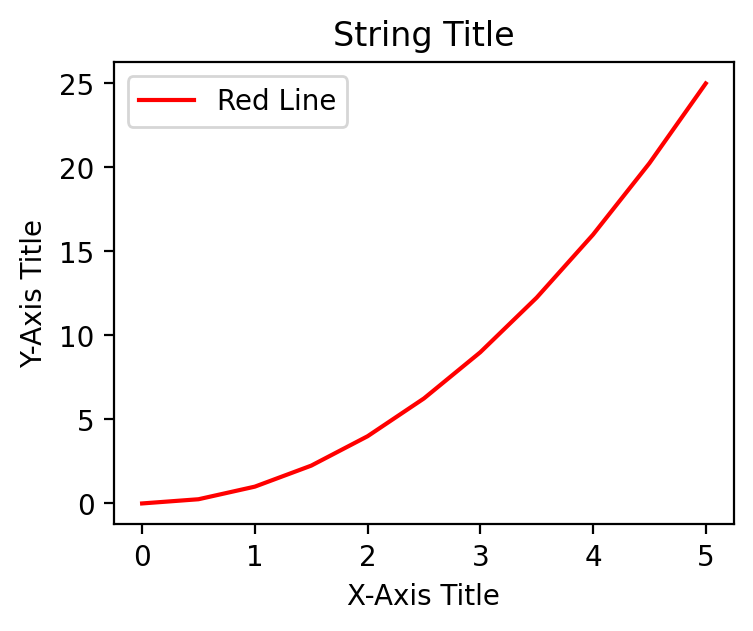

In [7]:
# plt.plot(x, y, 'r')           ### 'r' means color red
# plt.plot(x, y, c='r')         ### same as above, we saw this in Pandas plot

plt.figure(figsize=(4,3))
plt.plot(x, y, c='red', label='Red Line')         ### same as above, we saw this in Pandas plot
plt.xlabel('X-Axis Title')      ### in Pandas plot, this is automatic from column names
plt.ylabel('Y-Axis Title')      ### in Pandas plot, this is automatic from column names
plt.title('String Title')       ### in Pandas plot, this is "title="
plt.legend()                    ### to show the label we set above

The same plot can be created with Pandas plotting:


<Axes: title={'center': 'String Title'}, xlabel='X-Axis Title', ylabel='Y-Axis Title'>

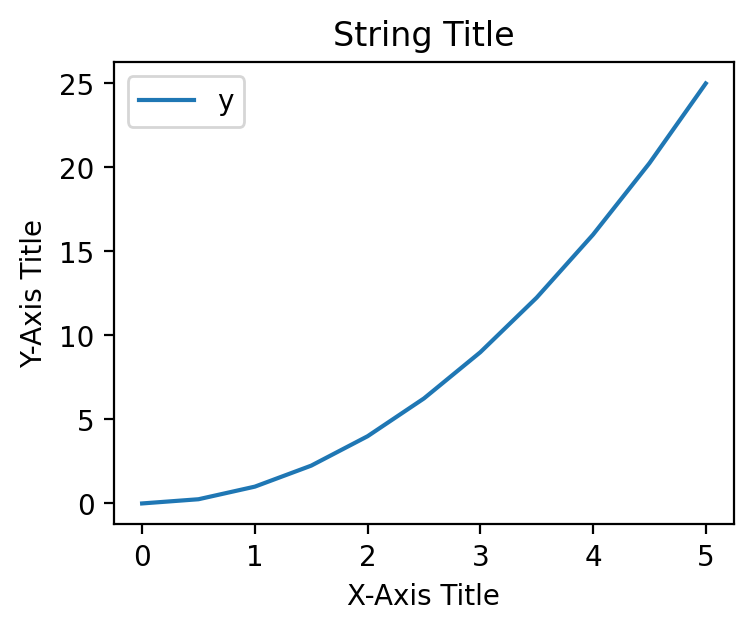

In [8]:
df = pd.DataFrame({'x': x, 'y': y}) ### DataFrame with two columns

# df.plot(x='x', y='y', kind="line")  ### line plot is default in Pandas; axes is automatically created             
# df.plot.line(x='x', y='y')          ### same as above
# df.plot(x='x', y='y')               ### same as above

df.plot(x = 'x', y = 'y', xlabel='X-Axis Title', ylabel='Y-Axis Title', title='String Title', figsize=(4,3))       
### all labels and title can be set in df.plot() directly or from dataframe column names

In [9]:
### Exercise: Basic plt.plot() with Customization
#   1. Create x_vals = np.linspace(0, 10, 50) and y_vals = np.sin(x_vals).
#   2. Use plt.figure(figsize=(4, 3)) to set the figure size.
#   3. Plot sin vs x_vals in red with the label "sin(x)".
#   4. Add an x-label "x", y-label "Amplitude", and title "Sine Wave".
#   5. Call plt.legend() to show the label.
### Your code starts here.




### Your code ends here.

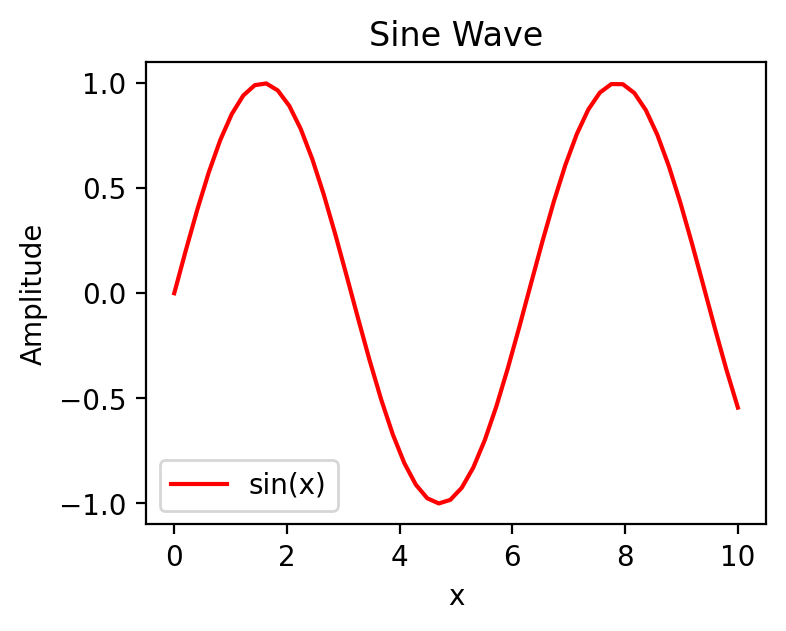

In [10]:
### Solution
### the data for the plot
x_vals = np.linspace(0, 10, 50)
y_vals = np.sin(x_vals)

### draw the plot with customizations
plt.figure(figsize=(4, 3))              ### this a figure
plt.plot(x_vals, y_vals, c='red', label='sin(x)') ### this is a plot in the figure

### formatting the plot with labels and title
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.title('Sine Wave')
plt.legend()


### Multiple Plots with `plt.subplot()`

`plt.subplot()` is the older pyplot-style way to place multiple axes in one figure. It is still useful to recognize, but for new code you will usually prefer `plt.subplots()`, which is clearer and fits the OO workflow better.

Syntax:

`plt.subplot(nrows, ncols, plot_number)`


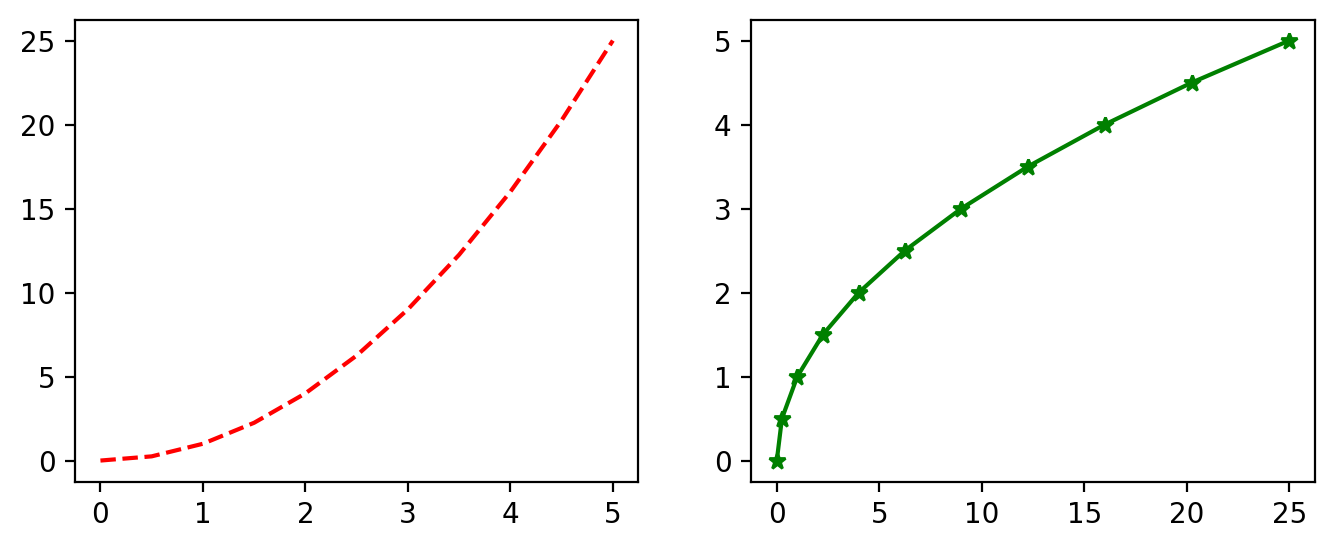

In [11]:
### plt.subplot(nrows, ncols, plot_number)   ### when you want multiple plots in one figure
### order is important, plot after subplot
plt.figure(figsize=(8,3))          ### create a figure first with specified size

plt.subplot(1, 2, 1)     ### subplot (axes, x-by-y) 1 of 1 row, 2 columns
plt.plot(x, y, 'r--')    ### 'r--' means red dashed line

plt.subplot(1, 2, 2)     ### subplot (axes) 2 of 1 row, 2 columns
plt.plot(y, x, 'g*-');   ### 'g*-' means green line with star markers

In [12]:
### Exercise: Multiple Subplots with plt.subplot()
#   1. Create x = np.linspace(0, 2*np.pi, 100).
#   2. Use plt.figure(figsize=(8, 3)) to set the figure size.
#   3. In subplot position (1, 2, 1), plot np.sin(x) with 'b-' and title "Sine".
#   4. In subplot position (1, 2, 2), plot np.cos(x) with 'g--' and title "Cosine".
### Your code starts here.




### Your code ends here.

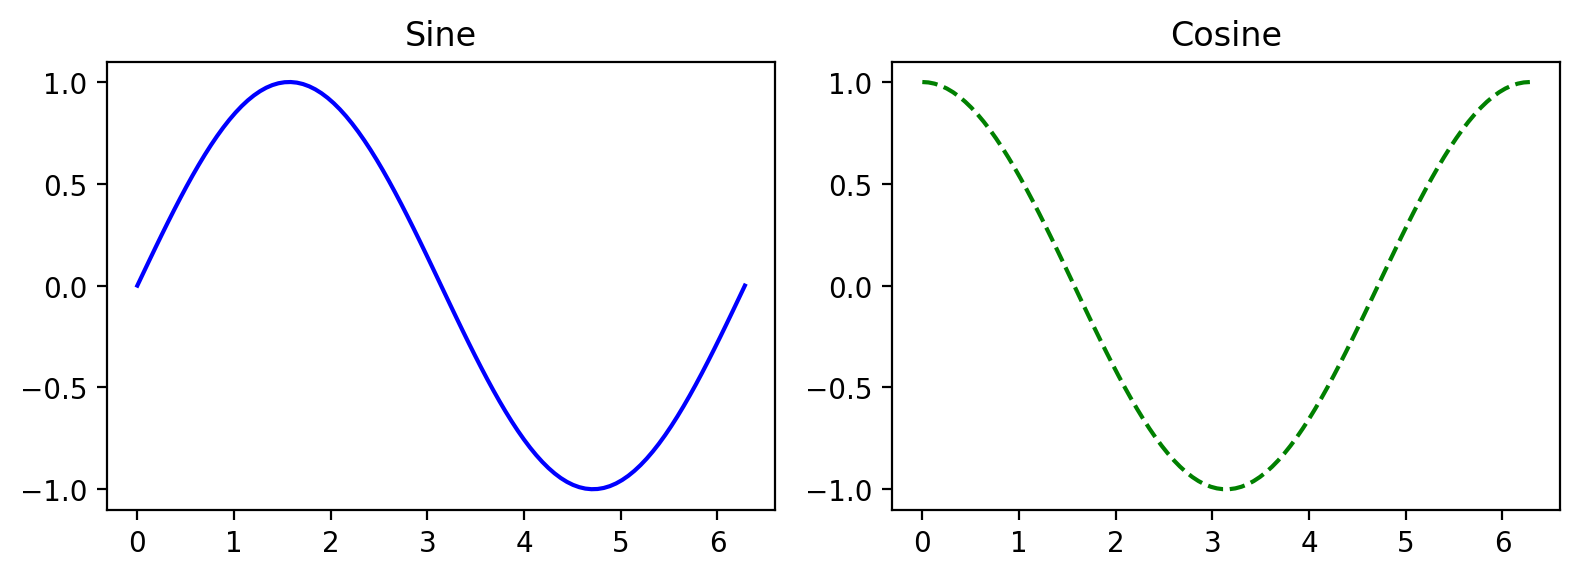

In [13]:
### Solution

x = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(x, np.sin(x), 'b-')
plt.title('Sine')

plt.subplot(1, 2, 2)
plt.plot(x, np.cos(x), 'g--')
plt.title('Cosine')

plt.tight_layout()